In [1]:
def vypocitej_faktory_presne(t_pocatecni, t_konecny, T1_pocatecni, T1_konecna, T2_pocatecni, T2_konecna, P, V1_litry=3.8, V2_litry=3.6, hustota_kg_m3=493.0):
    """
    Vypočítá chladicí (epsilon) a topný (tau) faktor s ohledem na objem a hustotu.
    """
    
    # Měrná tepelná kapacita vody (J / (kg * K))
    c = 4180 
    
    # Převod objemu z litrů na metry krychlové (1 litr = 0.001 m^3) 
    # a výpočet reálné hmotnosti: m = V * hustota
    m1 = (V1_litry / 1000) * hustota_kg_m3
    m2 = (V2_litry / 1000) * hustota_kg_m3
    
    # Výpočet časového intervalu (delta t) v sekundách
    delta_t = t_konecny - t_pocatecni
    
    if delta_t <= 0:
        return "Chyba: Časový interval musí být větší než 0."

    # Absolutní rozdíl teplot
    delta_T1 = abs(T1_konecna - T1_pocatecni)
    delta_T2 = abs(T2_konecna - T2_pocatecni)
    
    # Výpočet odebraného a dodaného tepla
    delta_Q1 = m1 * c * delta_T1
    delta_Q2 = m2 * c * delta_T2
    
    # Výpočet dodané elektrické energie
    W = P * delta_t
    
    # Výpočet chladicího a topného faktoru
    epsilon = delta_Q1 / W
    tau = delta_Q2 / W
    
    return epsilon, tau, m1, m2

# ==========================================
# PŘÍKLAD POUŽITÍ
# ==========================================

cas_1 = 0       # s
cas_2 = 600     # s

teplota_T1_start = 20.0  # °C
teplota_T1_konec = 15.0  # °C

teplota_T2_start = 20.0  # °C
teplota_T2_konec = 26.5  # °C

prikon_W = 130  

epsilon_vysledek, tau_vysledek, hm_1, hm_2 = vypocitej_faktory_presne(
    cas_1, cas_2, 
    teplota_T1_start, teplota_T1_konec, 
    teplota_T2_start, teplota_T2_konec, 
    prikon_W,
    V1_litry=3.8,    # Tvůj zadaný objem pro T1
    V2_litry=3.6,    # Tvůj zadaný objem pro T2
    hustota_kg_m3=493 # Tvá zadaná hustota
)

print(f"Vypočtená hmotnost m1: {hm_1:.2f} kg")
print(f"Vypočtená hmotnost m2: {hm_2:.2f} kg")
print(f"Chladicí faktor (epsilon): {epsilon_vysledek:.2f}")
print(f"Topný faktor (tau): {tau_vysledek:.2f}")

Vypočtená hmotnost m1: 1.87 kg
Vypočtená hmotnost m2: 1.77 kg
Chladicí faktor (epsilon): 0.50
Topný faktor (tau): 0.62


=== VÝSLEDKY EXPONENCIÁLNÍHO FITU VČETNĚ NEJISTOT ===
Vzorec použitý pro fitování: T(t) = a * exp(-b * t) + c

a = 23.6821 ± 0.1185
b = 0.013250 ± 0.000119
c = 28.3304 ± 0.1293

Výsledná rovnice fitu s chybami:
T(t) = (23.6821 ± 0.1185) * exp(-(0.013250 ± 0.000119) * t) + (28.3304 ± 0.1293)

Graf s chybovými úsečkami byl uložen jako 'exponencialni_fit_chladnuti_s_chybami.png'.


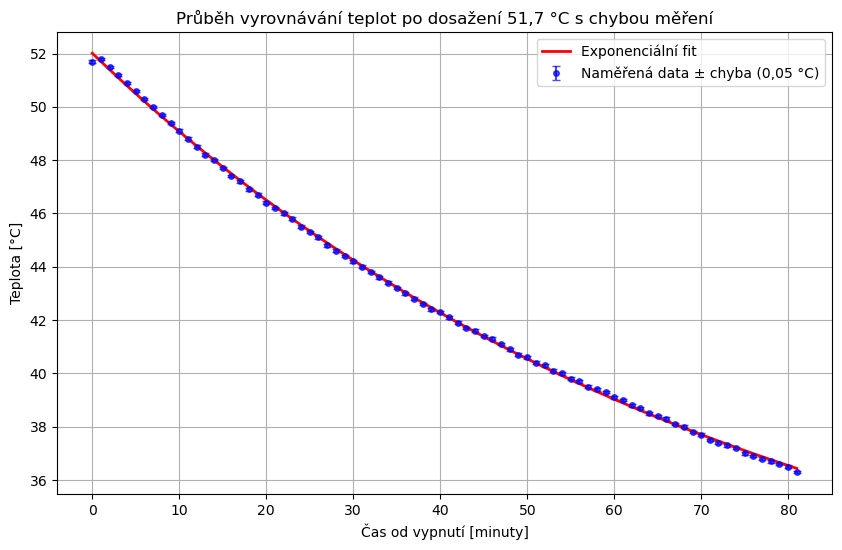

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from datetime import datetime

# 1. Definice exponenciální funkce
def exp_func(t, a, b, c):
    return a * np.exp(-b * t) + c

# Funkce pro převod času ("HH:MM:SS") na sekundy
def time_to_seconds(t_str):
    t = datetime.strptime(t_str, '%H:%M:%S')
    return t.hour * 3600 + t.minute * 60 + t.second

# 2. Načtení dat ze souboru
soubor = r"C:\Users\kubam\Desktop\Kuba\Fyzika\Praktikum\Praktikum I\XXVII\data_motycka_final (3).TXT"
data_lines = []

with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        # Čteme jen první tabulku s teplotami
        if 'T_plyn' in line or 'příkon' in line or not line.strip():
            break
        parts = line.strip().split('\t')
        if len(parts) >= 6:
            data_lines.append(parts[:6])

# Vytvoření DataFrame a úprava desetinných čárek
df = pd.DataFrame(data_lines, columns=['Datum', 'Cas', 'T_plyn', 'T_zkap', 'T_kom', 'T_pros'])
for col in ['T_plyn', 'T_zkap', 'T_kom', 'T_pros']:
    df[col] = df[col].str.replace(',', '.').astype(float)

# 3. Oříznutí dat na fázi chladnutí (od bodu vypnutí 51,7 °C)
start_idx = df.index[df['T_zkap'] == 51.7].tolist()[0]
df_cooling = df.iloc[start_idx:].copy()

# 4. Přepočet času na relativní minuty (t=0 je v bodě vypnutí)
df_cooling['Sekundy_abs'] = df_cooling['Cas'].apply(time_to_seconds)
t0 = df_cooling['Sekundy_abs'].iloc[0]
df_cooling['t_min'] = (df_cooling['Sekundy_abs'] - t0) / 60.0

x_data = df_cooling['t_min'].values
y_data = df_cooling['T_zkap'].values

# 5. Fitování s ohledem na chybu přístroje
chyba_teplomeru = 0.05  # Ve stupních Celsia
# Vytvoření pole chyb pro každý bod (konstantní chyba 0.05 pro všechna měření)
sigma = np.full(len(y_data), chyba_teplomeru)

p0 = [y_data[0] - 24.0, 0.05, 24.0]

# Provedení fitu s parametry sigma (váha bodů) a absolute_sigma (pro absolutní chybu)
popt, pcov = curve_fit(exp_func, x_data, y_data, p0=p0, sigma=sigma, absolute_sigma=True)
a, b, c = popt

# Výpočet směrodatných odchylek (chyb) z kovarianční matice
chyby = np.sqrt(np.diag(pcov))
chyba_a, chyba_b, chyba_c = chyby

# 6. Výpis výsledků
print("=== VÝSLEDKY EXPONENCIÁLNÍHO FITU VČETNĚ NEJISTOT ===")
print("Vzorec použitý pro fitování: T(t) = a * exp(-b * t) + c\n")
print(f"a = {a:.4f} ± {chyba_a:.4f}")
print(f"b = {b:.6f} ± {chyba_b:.6f}")
print(f"c = {c:.4f} ± {chyba_c:.4f}\n")
print("Výsledná rovnice fitu s chybami:")
print(f"T(t) = ({a:.4f} ± {chyba_a:.4f}) * exp(-({b:.6f} ± {chyba_b:.6f}) * t) + ({c:.4f} ± {chyba_c:.4f})")

# Vykreslení grafu s errorbary (chybovými úsečkami)
plt.figure(figsize=(10, 6))
# Zobrazení naměřených bodů včetně jejich chyby 0,05 °C
plt.errorbar(x_data, y_data, yerr=chyba_teplomeru, fmt='o', label='Naměřená data ± chyba (0,05 °C)', 
             color='blue', markersize=4, capsize=3, alpha=0.7)

x_fit = np.linspace(min(x_data), max(x_data), 200)
y_fit = exp_func(x_fit, *popt)

plt.plot(x_fit, y_fit, label='Exponenciální fit', color='red', linewidth=2)
plt.title('Průběh vyrovnávání teplot po dosažení 51,7 °C s chybou měření')
plt.xlabel('Čas od vypnutí [minuty]')
plt.ylabel('Teplota [°C]')
plt.legend()
plt.grid(True)
plt.savefig('exponencialni_fit_chladnuti_s_chybami.png')
print("\nGraf s chybovými úsečkami byl uložen jako 'exponencialni_fit_chladnuti_s_chybami.png'.")

In [8]:
import pandas as pd
from datetime import datetime

# 1. Funkce pro převod času ("HH:MM:SS") na sekundy
def time_to_seconds(t_str):
    t = datetime.strptime(t_str, '%H:%M:%S')
    return t.hour * 3600 + t.minute * 60 + t.second

# 2. Načtení dat ze souboru (z oříznuté verze, jak jsme to dělali u fitu)
soubor = r"C:\Users\kubam\Desktop\Kuba\Fyzika\Praktikum\Praktikum I\XXVII\data_motycka_final (3).TXT"
data_lines = []

with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        if 'T_plyn' in line or 'příkon' in line or not line.strip():
            break
        parts = line.strip().split('\t')
        if len(parts) >= 6:
            data_lines.append(parts[:6])

df = pd.DataFrame(data_lines, columns=['Datum', 'Cas', 'T_plyn', 'T_zkap', 'T_kom', 'T_pros'])
for col in ['T_plyn', 'T_zkap', 'T_kom', 'T_pros']:
    df[col] = df[col].str.replace(',', '.').astype(float)

# 3. Nalezení bodu vypnutí kompresoru (maximum teploty)
start_idx = df.index[df['T_zkap'] == 51.7].tolist()[0]
df_cooling = df.iloc[start_idx:].copy()

# 4. Parametry pro výpočet tepla
m_2 = 3.8        # Hmotnost vody ve zkapalňovači v kg (odpovídá 4 litrům)
c_voda = 4180.0  # Měrná tepelná kapacita vody v J/(kg.K)

# 5. Získání teplot a časů z dat
T_start = df_cooling['T_zkap'].iloc[0]      # Teplota na začátku chladnutí (51.7 °C)
T_end = df_cooling['T_zkap'].iloc[-1]       # Teplota na konci měření
delta_T = T_start - T_end                   # Celkový pokles teploty v Kelvinech / °C

cas_start_s = time_to_seconds(df_cooling['Cas'].iloc[0])
cas_end_s = time_to_seconds(df_cooling['Cas'].iloc[-1])
delta_t_s = cas_end_s - cas_start_s         # Celkový čas chladnutí v sekundách
delta_t_h = delta_t_s / 3600.0              # Čas v hodinách

# 6. Výpočet tepelných ztrát (Celkové odevzdané teplo)
delta_Q_joules = m_2 * c_voda * delta_T
delta_Q_kilo_joules = delta_Q_joules / 1000.0

# Výpočet průměrného tepelného ztrátového výkonu (Rychlost ztráty tepla)
P_ztraty_watty = delta_Q_joules / delta_t_s

# 7. Výpis výsledků
print("=== DOLNÍ ODHAD TEPELNÝCH ZTRÁT Z REZERVOÁRU ===")
print(f"Hmotnost vody (m2): {m_2} kg")
print(f"Měrná tepelná kapacita (c): {c_voda} J/(kg.K)")
print(f"Počáteční teplota při vypnutí: {T_start} °C")
print(f"Konečná teplota na konci měření: {T_end} °C")
print(f"Celkový pokles teploty (delta_T): {delta_T:.2f} °C\n")

print(f"Celkový čas chladnutí: {delta_t_s} sekund ({delta_t_s/60:.1f} minut)\n")

print(f"--> Dolní odhad celkových tepelných ztrát (delta_Q): {delta_Q_joules:.0f} J = {delta_Q_kilo_joules:.2f} kJ")
print(f"--> Průměrný tepelný ztrátový výkon do okolí: {P_ztraty_watty:.2f} W")

=== DOLNÍ ODHAD TEPELNÝCH ZTRÁT Z REZERVOÁRU ===
Hmotnost vody (m2): 3.8 kg
Měrná tepelná kapacita (c): 4180.0 J/(kg.K)
Počáteční teplota při vypnutí: 51.7 °C
Konečná teplota na konci měření: 36.3 °C
Celkový pokles teploty (delta_T): 15.40 °C

Celkový čas chladnutí: 4858 sekund (81.0 minut)

--> Dolní odhad celkových tepelných ztrát (delta_Q): 244614 J = 244.61 kJ
--> Průměrný tepelný ztrátový výkon do okolí: 50.35 W


Výpočet a graf hotov!


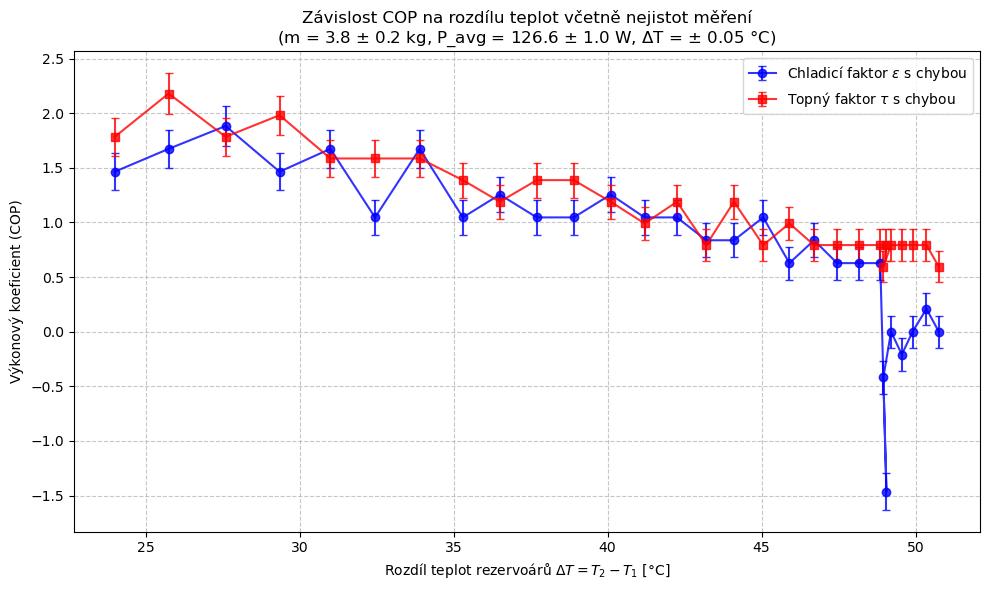

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat

# --- 1. Načtení a oříznutí dat ---
soubor = r"C:\Users\kubam\Desktop\Kuba\Fyzika\Praktikum\Praktikum I\XXVII\data_motycka_final (3).TXT"

data_teploty = []
with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        if 'T_plyn' in line or 'příkon' in line or not line.strip():
            break
        parts = line.strip().split('\t')
        if len(parts) >= 6:
            data_teploty.append(parts[:6])

df_temp = pd.DataFrame(data_teploty, columns=['Datum', 'Cas', 'T1', 'T2', 'T3', 'T4'])
for col in ['T1', 'T2', 'T3', 'T4']:
    df_temp[col] = df_temp[col].str.replace(',', '.').astype(float)

# Oříznutí teplot na ustálenou fázi
start_idx = df_temp.index[df_temp['T2'] >= 34.5].tolist()[0]
end_idx = df_temp.index[df_temp['T2'] >= 51.7].tolist()[0]
df_temp_filtered = df_temp.iloc[start_idx:end_idx+1].reset_index(drop=True)

data_tlaky = []
parse_active = False
with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        if 'příkon' in line and 'čas' in line:
            parse_active = True
            continue
        if parse_active:
            if 'vypnuto' in line or not line.strip():
                break
            parts = line.strip().split('\t')
            if len(parts) >= 9:
                prikon = parts[0].replace(',', '.')
                cas = parts[1].replace(',', '.')
                if prikon and cas:
                    data_tlaky.append([float(prikon), float(cas)])

df_press = pd.DataFrame(data_tlaky, columns=['Prikon', 'Cas_s'])
df_press_filtered = df_press[(df_press['Cas_s'] >= 480) & (df_press['Cas_s'] <= 2280)].reset_index(drop=True)

# Sjednocení délky
min_len = min(len(df_temp_filtered), len(df_press_filtered))
df_temp_filtered = df_temp_filtered.iloc[:min_len]
df_press_filtered = df_press_filtered.iloc[:min_len]

# --- 2. Výpočet termodynamických faktorů přes UNCERTAINTIES ---
# Konstanty (čas a měrná tepelná kapacita mají zanedbatelnou chybu)
c = 4180.0
dt = 60.0

# Veličiny s chybami (nominal_value, standard_deviation)
P_avg_val = df_press_filtered['Prikon'].mean()
P_u = ufloat(P_avg_val, 1.0) # Příkon s chybou +- 1 W
m_u1 = ufloat(3.8, 0.2)       # Hmotnost s chybou +- 0.2 kg
m_u2 = ufloat(3.6, 0.2)       # Hmotnost s chybou +- 0.2 kg
epsilons = []
err_epsilons = []
taus = []
err_taus = []
delta_Ts = []

for i in range(1, min_len):
    # Definice teplot s chybou +- 0.05 °C
    T1_start_u = ufloat(df_temp_filtered['T1'].iloc[i-1], 0.05)
    T1_end_u = ufloat(df_temp_filtered['T1'].iloc[i], 0.05)
    
    T2_start_u = ufloat(df_temp_filtered['T2'].iloc[i-1], 0.05)
    T2_end_u = ufloat(df_temp_filtered['T2'].iloc[i], 0.05)
    
    # Výpočet rozdílu teplot (balíček uncertainties se postará o šíření chyby)
    dT1_u = T1_start_u - T1_end_u 
    dT2_u = T2_end_u - T2_start_u
    
    # Výpočet COP
    epsilon_u = (c * m_u1 * dT1_u) / (P_u * dt)
    tau_u = (c * m_u2 * dT2_u) / (P_u * dt)
    
    # Pro osu X stačí hrubý průměr teplot (zde už chybu vykreslovat nebudeme)
    T1_avg = (df_temp_filtered['T1'].iloc[i] + df_temp_filtered['T1'].iloc[i-1]) / 2.0
    T2_avg = (df_temp_filtered['T2'].iloc[i] + df_temp_filtered['T2'].iloc[i-1]) / 2.0
    delta_T = T2_avg - T1_avg
    
    # Rozložení hodnot na .n (nominální) a .s (standardní odchylka / chyba)
    epsilons.append(epsilon_u.n)
    err_epsilons.append(epsilon_u.s)
    
    taus.append(tau_u.n)
    err_taus.append(tau_u.s)
    
    delta_Ts.append(delta_T)

# Export s chybami do CSV
out_df = pd.DataFrame({
    'Rozdil_Teplot_dT': delta_Ts, 
    'Chladici_faktor': epsilons, 'Chyba_Chladiciho_faktoru': err_epsilons,
    'Topny_faktor': taus, 'Chyba_Topneho_faktoru': err_taus
})
out_df.to_csv('faktory_vypocet_s_chybami.csv', index=False)

# --- 3. Vykreslení grafu s Errorbary ---
plt.figure(figsize=(10, 6))

# Vykreslení bodů vč. chybových úseček (yerr)
plt.errorbar(delta_Ts, epsilons, yerr=err_epsilons, fmt='b-o', label='Chladicí faktor $\epsilon$ s chybou', capsize=3, alpha=0.8)
plt.errorbar(delta_Ts, taus, yerr=err_taus, fmt='r-s', label='Topný faktor $\\tau$ s chybou', capsize=3, alpha=0.8)



plt.xlabel('Rozdíl teplot rezervoárů $\Delta T = T_2 - T_1$ [°C]')
plt.ylabel('Výkonový koeficient (COP)')
plt.title(f'Závislost COP na rozdílu teplot včetně nejistot měření\n(m = 3.8 ± 0.2 kg, P_avg = {P_avg_val:.1f} ± 1.0 W, $\Delta$T = ± 0.05 °C)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig('faktory_graf_s_chybami.png', dpi=300)
print("Výpočet a graf hotov!")

Grafy byly uloženy do souboru 'zavislosti_kompresor_ustaleny_stav_s_chybami.png'.


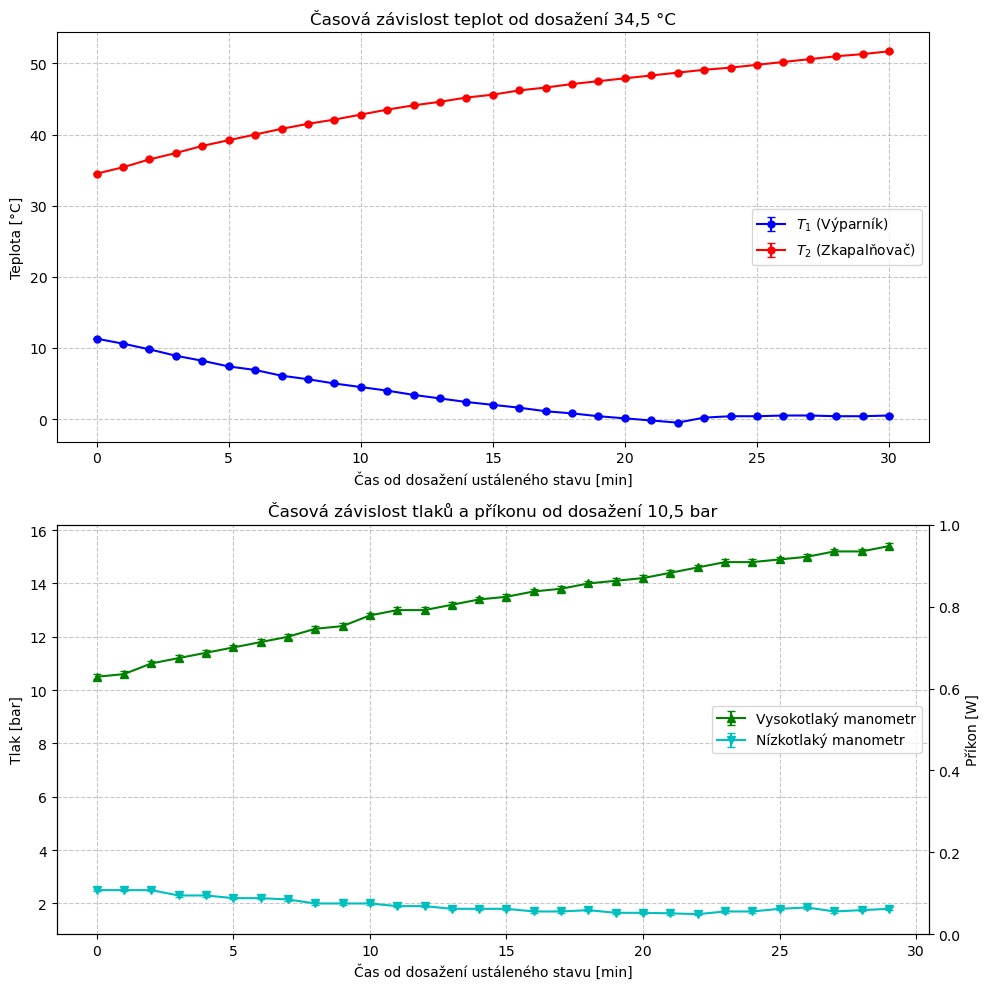

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import uncertainties.unumpy as unp  # Knihovna pro práci s nejistotami/chybami

# ZADEJ CESTU K TVÉMU DATOVÉMU SOUBORU
soubor = r"C:\Users\kubam\Desktop\Kuba\Fyzika\Praktikum\Praktikum I\XXVII\data_motycka_final (3).TXT"

# ==========================================
# 1. ZPRACOVÁNÍ TABULKY TEPLOT (1. ČÁST DOKUMENTU)
# ==========================================
data_teploty = []
with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        # Čteme do doby, než začne tabulka příkonů a tlaků
        if 'T_plyn' in line or 'příkon' in line or not line.strip():
            break
        parts = line.strip().split('\t')
        if len(parts) >= 6:
            data_teploty.append(parts[:6])

df_temp = pd.DataFrame(data_teploty, columns=['Datum', 'Cas', 'T1', 'T2', 'T3', 'T4'])
# Nahrazení čárek za tečky a převod na čísla
for col in ['T1', 'T2', 'T3', 'T4']:
    df_temp[col] = df_temp[col].str.replace(',', '.').astype(float)

# Nalezení indexu od řádku, kde je teplota T2 minimálně 34.5 °C (START)
start_idx_temp = df_temp.index[df_temp['T2'] >= 34.5].tolist()[0]
# Nalezení indexu, kde je teplota 51.7 °C (KONEC = vypnutí kompresoru)
end_idx_temp = df_temp.index[df_temp['T2'] >= 51.7].tolist()[0]

# Oříznutí dat teplot
df_temp_filtered = df_temp.iloc[start_idx_temp:end_idx_temp+1].copy()
# Nastavení relativního času od 0 (krok byl 1 minuta)
df_temp_filtered['t_rel_min'] = np.arange(len(df_temp_filtered)) 

# Definice chyb pro teplotu pomocí uncertainties (0,05 °C)
u_T1 = unp.uarray(df_temp_filtered['T1'], 0.05)
u_T2 = unp.uarray(df_temp_filtered['T2'], 0.05)


# ==========================================
# 2. ZPRACOVÁNÍ TABULKY TLAKŮ A PŘÍKONU (2. ČÁST DOKUMENTU)
# ==========================================
data_tlaky = []
parse_active = False
with open(soubor, 'r', encoding='utf-8') as f:
    for line in f:
        # Hledáme začátek druhé tabulky podle hlavičky
        if 'příkon' in line and 'čas' in line:
            parse_active = True
            continue
        if parse_active:
            if 'vypnuto' in line or not line.strip():
                break
            parts = line.strip().split('\t')
            # Zajímá nás jen řádek, kde jsou zapsané všechny hodnoty
            if len(parts) >= 9:
                prikon = parts[0].replace(',', '.')
                cas = parts[1].replace(',', '.')
                p_vys = parts[7].replace(',', '.')
                p_niz = parts[8].replace(',', '.')
                
                if prikon and cas and p_vys and p_niz:
                    data_tlaky.append([float(prikon), float(cas), float(p_vys), float(p_niz)])

df_press = pd.DataFrame(data_tlaky, columns=['Prikon', 'Cas_s', 'P_vys', 'P_niz'])
df_press['t_min'] = df_press['Cas_s'] / 60.0

# Výběr dat od 8. minuty (480 sekund), kdy vysoký tlak dosáhl 10.5 bar
df_press_filtered = df_press[df_press['Cas_s'] >= 480].copy()

# Oříznutí konce zhruba na úroveň vypnutí (v datech kolem 37. minuty / 2220 s)
df_press_filtered = df_press_filtered[df_press_filtered['Cas_s'] <= 2280].copy()

# Posunutí času tak, aby startoval na 0 (pro srovnání s grafem teplot)
t0_press = df_press_filtered['t_min'].iloc[0]
df_press_filtered['t_rel_min'] = df_press_filtered['t_min'] - t0_press

# Definice chyb pro tlaky pomocí uncertainties
# Vysokotlaký: 0.1 Bar, Nízkotlaký: 0.05 Bar
u_P_vys = unp.uarray(df_press_filtered['P_vys'], 0.1)
u_P_niz = unp.uarray(df_press_filtered['P_niz'], 0.05)


# ==========================================
# 3. VYKRESLENÍ GRAFŮ
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# -- Graf 1: Teploty (Výparník a Zkapalňovač) --
# Místo klasického plot používáme errorbar s parametrem yerr pro zobrazení chybových úseček
ax1.errorbar(df_temp_filtered['t_rel_min'], unp.nominal_values(u_T1), yerr=unp.std_devs(u_T1), 
             fmt='b-o', label='$T_1$ (Výparník)', markersize=5, capsize=3)
ax1.errorbar(df_temp_filtered['t_rel_min'], unp.nominal_values(u_T2), yerr=unp.std_devs(u_T2), 
             fmt='r-o', label='$T_2$ (Zkapalňovač)', markersize=5, capsize=3)

ax1.set_title('Časová závislost teplot od dosažení 34,5 °C', fontsize=12)
ax1.set_xlabel('Čas od dosažení ustáleného stavu [min]')
ax1.set_ylabel('Teplota [°C]')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='center right')


# -- Graf 2: Tlaky a příkon --
# Vytvoření druhé osy Y pro příkon, jelikož Watty a Bary mají jiné rozmezí
ax2_p = ax2.twinx() 
ax2.errorbar(df_press_filtered['t_rel_min'], unp.nominal_values(u_P_vys), yerr=unp.std_devs(u_P_vys), 
             fmt='g-^', label='Vysokotlaký manometr', markersize=6, capsize=3)
ax2.errorbar(df_press_filtered['t_rel_min'], unp.nominal_values(u_P_niz), yerr=unp.std_devs(u_P_niz), 
             fmt='c-v', label='Nízkotlaký manometr', markersize=6, capsize=3)
# U příkonu chyba nebyla specifikována, proto jej necháváme přes ax.plot
#ax2_p.plot(df_press_filtered['t_rel_min'], df_press_filtered['Prikon'], 'm-s', label='Elektrický příkon', markersize=5)

ax2.set_title('Časová závislost tlaků a příkonu od dosažení 10,5 bar', fontsize=12)
ax2.set_xlabel('Čas od dosažení ustáleného stavu [min]')
ax2.set_ylabel('Tlak [bar]')
ax2_p.set_ylabel('Příkon [W]')
ax2.grid(True, linestyle='--', alpha=0.7)

# Sloučení legend do jednoho boxu pro druhý graf
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_p.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

# Zarovnání a uložení
plt.tight_layout()
plt.savefig('zavislosti_kompresor_ustaleny_stav_s_chybami.png', dpi=300)
print("Grafy byly uloženy do souboru 'zavislosti_kompresor_ustaleny_stav_s_chybami.png'.")